# Evaluación Formativa 2: Práctica de Modelamiento Predictivo

**Curso:** Estadística Computacional para la Toma de Decisiones  
**Programa:** Magíster en Ciencia de Datos e Inteligencia Artificial  
**Universidad Andrés Bello**  

---

## Información del Equipo

| Campo | Información |
|-------|-------------|
| **Número de Grupo** | 6 |
| **Integrante 1** | Gonzalo Bouldres] |
| **Integrante 2** | Eduardo Contreras |
| **Integrante 3** | Luis Díaz Giral |
| **Dataset Seleccionado** | weatherAUS - Lluvia en Australia |

### Objetivo

Construir un modelo de regresión logística para predecir la ocurrencia de lluvia al día siguiente (RainTomorrow), reutilizando los resultados obtenidos durante la Sumativa 1 y Sumativa 2.

En esta actividad se evaluará el impacto del preprocesamiento realizado anteriormente mediante la comparación entre un modelo base y un modelo optimizado.

# Introducción metodológica

## Contexto del trabajo

La presente evaluación formativa tiene como propósito desarrollar un modelo de regresión logística para predecir la ocurrencia de lluvia al día siguiente (`RainTomorrow`) utilizando el conjunto de datos **Weather Australia**. Este trabajo constituye la continuidad de las Evaluaciones Sumativas 1 y 2, integrando los resultados obtenidos previamente durante el análisis exploratorio, la validación estadística de variables y la preparación del conjunto de datos.

A diferencia de un ejercicio aislado de modelamiento, el presente notebook mantiene la trazabilidad metodológica del proyecto, reutilizando las decisiones analíticas adoptadas en las etapas anteriores y justificando cada procedimiento realizado durante la construcción del modelo predictivo.

---

## Objetivo general

Construir y evaluar un modelo de regresión logística que permita predecir la variable **RainTomorrow**, integrando los resultados obtenidos en las evaluaciones anteriores y justificando metodológicamente cada una de las decisiones adoptadas durante el proceso de preparación de datos, entrenamiento y evaluación del modelo.

---

## Estrategia metodológica

El desarrollo del notebook sigue el flujo recomendado para proyectos de Ciencia de Datos y Machine Learning, organizado en etapas secuenciales que permiten garantizar la reproducibilidad del análisis.

En primer lugar, se realiza la preparación del entorno de trabajo y la carga del conjunto de datos previamente procesado durante la Sumativa 2. Posteriormente, se documentan los principales hallazgos obtenidos en las evaluaciones anteriores, incorporando explícitamente las variables seleccionadas, las correlaciones validadas y las decisiones metodológicas relacionadas con el tratamiento de datos.

Como etapa previa al modelamiento, se desarrolla una comparación experimental entre distintas estrategias de tratamiento de valores faltantes. En lugar de seleccionar una técnica de manera arbitraria, se evalúa el efecto de cada estrategia sobre el desempeño predictivo del modelo y sobre la cantidad de información conservada, permitiendo fundamentar objetivamente la estrategia utilizada durante el resto del trabajo.

Una vez seleccionado el conjunto de datos definitivo, se construye un modelo de regresión logística utilizando las variables predictoras previamente justificadas mediante análisis exploratorio y validación estadística. Posteriormente, el modelo es evaluado desde dos perspectivas complementarias.

La primera corresponde a la evaluación predictiva, desarrollada mediante la librería **Scikit-Learn**, utilizando métricas como Accuracy, Precision, Recall, F1-Score, matriz de confusión y Área Bajo la Curva ROC (AUC).

La segunda corresponde al análisis inferencial, desarrollado mediante la librería **Statsmodels**, permitiendo interpretar los coeficientes del modelo, calcular los Odds Ratio, evaluar la significancia estadística de cada predictor y diagnosticar posibles problemas de multicolinealidad mediante el Factor de Inflación de la Varianza (VIF).

Finalmente, el notebook concluye con una síntesis crítica de los resultados obtenidos, integrando los hallazgos de las Sumativas 1 y 2, evaluando las fortalezas y limitaciones del modelo construido y proponiendo líneas de mejora para la Evaluación Sumativa 3.

---

## Flujo metodológico del notebook

El desarrollo del presente trabajo sigue la siguiente secuencia metodológica:

1. Configuración del entorno de trabajo.
2. Carga y auditoría inicial del conjunto de datos.
3. Integración de resultados provenientes de la Sumativa 1 y Sumativa 2.
4. Comparación de estrategias de tratamiento de valores faltantes.
5. Selección del conjunto de datos definitivo.
6. Construcción del modelo de regresión logística.
7. Interpretación preliminar de los coeficientes del modelo.
8. Análisis inferencial mediante Statsmodels.
9. Diagnóstico de multicolinealidad mediante VIF.
10. Evaluación del desempeño predictivo mediante métricas de clasificación.
11. Síntesis y reflexión metodológica.

---

## Consideraciones de reproducibilidad

Con el propósito de favorecer la reproducibilidad del análisis, todas las etapas del proceso fueron desarrolladas mediante código Python ejecutable dentro de un Notebook de Jupyter. Asimismo, las figuras, tablas y resultados generados durante la ejecución son almacenados automáticamente dentro de la estructura del proyecto, permitiendo reconstruir completamente el proceso analítico sin necesidad de realizar modificaciones manuales.

Esta estrategia asegura la transparencia metodológica del trabajo y facilita futuras extensiones del proyecto durante la Evaluación Sumativa 3.

# PARTE 1: Preparación de Datos para Modelamiento

En esta primera etapa se prepara el conjunto de datos que será utilizado durante el proceso de modelamiento predictivo. La preparación incorpora los principales hallazgos obtenidos en las Evaluaciones Sumativas 1 y 2, permitiendo mantener la continuidad metodológica del proyecto y justificando cada decisión adoptada durante la construcción del modelo.

In [1]:
# ============================================================
# Carga de librerías
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)


In [2]:
# ============================================================
# Configuración de rutas del proyecto
# ============================================================

ROOT = Path.cwd().parent

DATA_PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "docs" / "figures"
TABLES = ROOT / "docs" / "tables"

FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

print("Ruta raíz:", ROOT)
print("Carpeta de datos procesados:", DATA_PROCESSED)
print("Carpeta de figuras:", FIGURES)
print("Carpeta de tablas:", TABLES)

Ruta raíz: C:\Users\luisd\magister\curso 2\mcdia501-estadistica-computacional-g6\semana3
Carpeta de datos procesados: C:\Users\luisd\magister\curso 2\mcdia501-estadistica-computacional-g6\semana3\data\processed
Carpeta de figuras: C:\Users\luisd\magister\curso 2\mcdia501-estadistica-computacional-g6\semana3\docs\figures
Carpeta de tablas: C:\Users\luisd\magister\curso 2\mcdia501-estadistica-computacional-g6\semana3\docs\tables


In [3]:
# ============================================================
# Verificación de archivos disponibles
# ============================================================

# Se listan los archivos CSV disponibles en la carpeta data/processed.
# Esto permite confirmar que el notebook está leyendo correctamente
# la estructura del proyecto antes de cargar el dataset.

for archivo in DATA_PROCESSED.glob("*.csv"):
    print(archivo.name)

resultados_validados_sumativa2.csv
weatherAUS_sumativa2_base_validacion.csv


## 1.1 Carga y Referencia a S1/S2

La construcción del modelo predictivo requiere utilizar como punto de partida el conjunto de datos previamente validado durante las evaluaciones anteriores. En esta sección se carga la base consolidada y posteriormente se recuperan los principales hallazgos obtenidos en la Sumativa 1 y Sumativa 2, los cuales fundamentan las decisiones metodológicas adoptadas durante el modelamiento.

La integración de los resultados obtenidos en las Sumativas 1 y 2 constituye un elemento central del presente trabajo. Mientras la Sumativa 1 permitió caracterizar el conjunto de datos mediante análisis exploratorio, la Sumativa 2 validó estadísticamente las relaciones identificadas utilizando técnicas de remuestreo. En consecuencia, el proceso de modelamiento desarrollado en esta evaluación se fundamenta en evidencia previamente validada y no en decisiones arbitrarias.

In [4]:
# ============================================================
# Carga del dataset validado
# ============================================================

# Se carga la base de datos procesada en etapas anteriores.
# Esta base será utilizada como insumo principal para la Formativa 2.

df = pd.read_csv(
    DATA_PROCESSED / "weatherAUS_sumativa2_base_validacion.csv"
)

# Se visualizan las primeras filas para comprobar que la carga fue correcta.
df.head()

,Date,Location,Year,Month,Season,MinTemp,MaxTemp,Humidity3pm,Pressure3pm,Rainfall,WindDir9am,RainToday,RainTomorrow,RainToday_bin,RainTomorrow_bin
0,2008-12-01,Albury,2008,12,Summer,13.4,22.9,22.0,1007.1,0.6,W,No,No,0.0,0.0
1,2008-12-02,Albury,2008,12,Summer,7.4,25.1,25.0,1007.8,0.0,NNW,No,No,0.0,0.0
2,2008-12-03,Albury,2008,12,Summer,12.9,25.7,30.0,1008.7,0.0,W,No,No,0.0,0.0
3,2008-12-04,Albury,2008,12,Summer,9.2,28.0,16.0,1012.8,0.0,SE,No,No,0.0,0.0
4,2008-12-05,Albury,2008,12,Summer,17.5,32.3,33.0,1006.0,1.0,ENE,No,No,0.0,0.0


In [5]:
# ============================================================
# Auditoría inicial del dataset
# ============================================================

# Se revisan las dimensiones generales del dataset.
print("Dimensiones del dataset:", df.shape)

# Se revisa la estructura de columnas y tipos de datos.
display(df.dtypes)

# Se cuantifican los valores faltantes por variable.
valores_faltantes = df.isna().sum().sort_values(ascending=False)

display(valores_faltantes)

Dimensiones del dataset: (145460, 15)


Date                    str
Location                str
Year                  int64
Month                 int64
Season                  str
MinTemp             float64
MaxTemp             float64
Humidity3pm         float64
Pressure3pm         float64
Rainfall            float64
WindDir9am              str
RainToday               str
RainTomorrow            str
RainToday_bin       float64
RainTomorrow_bin    float64
dtype: object

Pressure3pm         15028
WindDir9am          10566
Humidity3pm          4507
RainTomorrow         3267
RainTomorrow_bin     3267
Rainfall             3261
RainToday            3261
RainToday_bin        3261
MinTemp              1485
MaxTemp              1261
Month                   0
Date                    0
Season                  0
Location                0
Year                    0
dtype: int64

## Integración de resultados de S1 y S2

La Formativa 2 no se desarrolla de forma aislada, sino que utiliza como insumo los hallazgos obtenidos en las evaluaciones anteriores.

Desde la Sumativa 1 se consideran los resultados del análisis exploratorio, especialmente la identificación de valores faltantes, outliers y variables con posible relación con la variable objetivo `RainTomorrow`.

Desde la Sumativa 2 se incorporan los resultados de validación mediante remuestreo, correlaciones estables y parámetros robustos, con el propósito de seleccionar variables predictoras metodológicamente justificadas para el modelo de regresión logística.

In [6]:
# ============================================================
# Definición de variable objetivo y variables candidatas
# ============================================================

# Se define la variable objetivo del problema de clasificación.
# En este caso, se busca predecir si lloverá al día siguiente.
variable_objetivo = "RainTomorrow"

# Se definen variables predictoras candidatas en función de los análisis
# realizados previamente en S1 y S2.
# Estas variables deben estar presentes en el dataset cargado.
variables_candidatas = [
    "Humidity3pm",
    "RainToday",
    "Pressure3pm",
    "Sunshine",
    "Cloud3pm"
]

# Se verifica cuáles variables candidatas existen efectivamente en el dataset.
variables_disponibles = [
    col for col in variables_candidatas
    if col in df.columns
]

# Se muestran las variables finalmente disponibles para modelamiento.
print("Variable objetivo:", variable_objetivo)
print("Variables candidatas disponibles:", variables_disponibles)

Variable objetivo: RainTomorrow
Variables candidatas disponibles: ['Humidity3pm', 'RainToday', 'Pressure3pm']


In [7]:
# ============================================================
# Validación de columnas requeridas
# ============================================================

# Se verifica que la variable objetivo exista en el dataset.
if variable_objetivo not in df.columns:
    raise ValueError(f"La variable objetivo {variable_objetivo} no existe en el dataset.")

# Se verifica que exista al menos una variable predictora disponible.
if len(variables_disponibles) == 0:
    raise ValueError("No se encontraron variables predictoras disponibles en el dataset.")

# Se crea una copia de trabajo solo con las variables necesarias.
df_modelo = df[variables_disponibles + [variable_objetivo]].copy()

# Se revisan las primeras filas del dataset de modelamiento.
df_modelo.head()

,Humidity3pm,RainToday,Pressure3pm,RainTomorrow
0,22.0,No,1007.1,No
1,25.0,No,1007.8,No
2,30.0,No,1008.7,No
3,16.0,No,1012.8,No
4,33.0,No,1006.0,No


In [8]:
# ============================================================
# Revisión de valores faltantes en variables del modelo
# ============================================================

# Se cuantifican los valores faltantes solamente en las variables
# que serán utilizadas para el modelamiento predictivo.
faltantes_modelo = df_modelo.isna().sum().sort_values(ascending=False)

# Se muestra la cantidad de valores faltantes por variable.
display(faltantes_modelo)

Pressure3pm     15028
Humidity3pm      4507
RainTomorrow     3267
RainToday        3261
dtype: int64

## Evaluación de estrategias de tratamiento de valores faltantes

Antes de construir el modelo definitivo, se comparan distintas estrategias de tratamiento de valores faltantes.

El objetivo consiste en determinar experimentalmente cuál de ellas produce el mejor desempeño predictivo, considerando tanto la calidad del modelo como la conservación de información.

Las estrategias evaluadas son:

- Eliminación de registros incompletos (Drop).
- Imputación mediante la mediana para variables numéricas.
- (Opcional) Imputación mediante la media para fines comparativos.

Posteriormente se seleccionará la estrategia con mejores resultados para construir el modelo final.

La existencia de valores faltantes representa uno de los principales desafíos durante la preparación de datos. Por este motivo, antes de construir el modelo definitivo se comparan distintas estrategias de tratamiento, evaluando simultáneamente el porcentaje de información conservada y el impacto sobre el desempeño predictivo del modelo.

In [9]:
# ============================================================
# Construcción de datasets comparativos
# ============================================================

# Dataset original
df_original = df_modelo.copy()

# Dataset utilizando eliminación de registros
df_drop = df_original.dropna().copy()

# Dataset utilizando imputación por mediana
df_mediana = df_original.copy()

for columna in df_mediana.select_dtypes(include=np.number).columns:

    df_mediana[columna] = df_mediana[columna].fillna(
        df_mediana[columna].median()
    )

## Comparación de registros conservados por estrategia

Antes de evaluar el desempeño predictivo, se compara la cantidad de registros disponibles bajo cada estrategia de tratamiento de valores faltantes.

Esta comparación es relevante porque una estrategia como `dropna()` puede mejorar la limpieza del dataset, pero también puede eliminar una proporción importante de observaciones. En cambio, la imputación permite conservar más información, aunque introduce valores estimados.

Por lo tanto, la decisión metodológica no se basará solo en métricas predictivas, sino también en la conservación de información.

El porcentaje de registros conservados constituye un criterio complementario al desempeño predictivo. Una estrategia que elimine una cantidad considerable de observaciones puede mejorar marginalmente las métricas del modelo, pero disminuir la representatividad del conjunto de datos utilizado para el entrenamiento.

In [10]:
# ============================================================
# Comparación de registros conservados
# ============================================================

# Se construye una tabla para comparar cuántos registros conserva
# cada estrategia de tratamiento de valores faltantes.

comparacion_dataset = pd.DataFrame({
    "Estrategia": [
        "Original",
        "Eliminación de registros incompletos",
        "Imputación por mediana"
    ],
    "Registros": [
        len(df_original),
        len(df_drop),
        len(df_mediana)
    ]
})

# Se calcula el porcentaje de conservación respecto del dataset original.
comparacion_dataset["Porcentaje_conservacion"] = (
    comparacion_dataset["Registros"] / len(df_original) * 100
).round(2)

# Se visualiza la tabla.
display(comparacion_dataset)

# Se guarda la tabla como evidencia reproducible.
comparacion_dataset.to_csv(
    TABLES / "comparacion_registros_estrategias.csv",
    index=False
)

,Estrategia,Registros,Porcentaje_conservacion
0,Original,145460,100.00
1,Eliminación de registros incompletos,124791,85.79
2,Imputación por mediana,145460,100.00


## Función de evaluación predictiva

Para comparar las estrategias de tratamiento de valores faltantes de manera justa y reproducible, se define una función que aplica exactamente el mismo flujo de modelamiento a cada dataset.

La función realiza los siguientes pasos:

1. Separa variables predictoras y variable objetivo.
2. Divide los datos en entrenamiento y prueba usando una proporción 70/30.
3. Estandariza las variables predictoras.
4. Ajusta un modelo de regresión logística.
5. Genera predicciones sobre el conjunto de prueba.
6. Calcula métricas de desempeño: Accuracy, Precision, Recall, F1-Score y AUC.

Este diseño permite que la comparación entre estrategias dependa del tratamiento de valores faltantes y no de diferencias en el procedimiento de modelamiento.

Con el propósito de garantizar una comparación objetiva entre las distintas estrategias evaluadas, se implementa una función que automatiza completamente el proceso de entrenamiento y evaluación. De esta forma, todas las estrategias son sometidas exactamente al mismo procedimiento experimental, asegurando que las diferencias observadas correspondan únicamente al tratamiento aplicado sobre los datos.

In [11]:
# ============================================================
# Función corregida para evaluar regresión logística
# ============================================================

def evaluar_modelo_logistico(
    df_entrada,
    variables_predictoras,
    variable_objetivo,
    nombre_estrategia
):
    """
    Evalúa un modelo de regresión logística para una estrategia
    específica de tratamiento de valores faltantes.
    """

    # ------------------------------------------------------------
    # 1. Copia del dataset
    # ------------------------------------------------------------
    df_temp = df_entrada.copy()

    # ------------------------------------------------------------
    # 2. Codificación de variables categóricas binarias
    # ------------------------------------------------------------
    # Se reemplazan valores textuales "No" y "Yes" por 0 y 1.
    # Esto es necesario porque los modelos de sklearn trabajan
    # con variables numéricas.
    df_temp = df_temp.replace({
        "No": 0,
        "Yes": 1
    })

    # ------------------------------------------------------------
    # 3. Eliminación preventiva de registros sin variable objetivo
    # ------------------------------------------------------------
    # La variable objetivo no debe contener valores faltantes.
    df_temp = df_temp.dropna(subset=[variable_objetivo])

    # ------------------------------------------------------------
    # 4. Separación de variables predictoras y variable objetivo
    # ------------------------------------------------------------
    X = df_temp[variables_predictoras]
    y = df_temp[variable_objetivo].astype(int)

    # ------------------------------------------------------------
    # 5. Validación de tipos de datos
    # ------------------------------------------------------------
    # Se fuerza la conversión de las variables predictoras a numéricas.
    # Si algún valor no puede convertirse, se transforma en NaN.
    X = X.apply(pd.to_numeric, errors="coerce")

    # ------------------------------------------------------------
    # 6. Eliminación de cualquier fila residual con NaN
    # ------------------------------------------------------------
    # Esto evita errores en el escalamiento o entrenamiento.
    dataset_modelo = pd.concat([X, y], axis=1).dropna()

    X = dataset_modelo[variables_predictoras]
    y = dataset_modelo[variable_objetivo].astype(int)

    # ------------------------------------------------------------
    # 7. División en entrenamiento y prueba 70/30
    # ------------------------------------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )

    # ------------------------------------------------------------
    # 8. Estandarización de variables predictoras
    # ------------------------------------------------------------
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # ------------------------------------------------------------
    # 9. Ajuste del modelo de regresión logística
    # ------------------------------------------------------------
    modelo = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

    modelo.fit(X_train_scaled, y_train)

    # ------------------------------------------------------------
    # 10. Predicciones
    # ------------------------------------------------------------
    y_pred = modelo.predict(X_test_scaled)
    y_prob = modelo.predict_proba(X_test_scaled)[:, 1]

    # ------------------------------------------------------------
    # 11. Métricas
    # ------------------------------------------------------------
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)

    # ------------------------------------------------------------
    # 12. Resultado
    # ------------------------------------------------------------
    resultado = {
        "Estrategia": nombre_estrategia,
        "Registros": len(dataset_modelo),
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-Score": round(f1, 4),
        "AUC": round(auc, 4)
    }

    return resultado

## Evaluación de estrategias de tratamiento

En este bloque se aplica la función de evaluación a cada dataset construido previamente.

Se comparan dos estrategias principales:

- Eliminación de registros incompletos.
- Imputación por mediana.

Ambas estrategias son evaluadas con el mismo modelo, las mismas variables predictoras, la misma proporción train/test y el mismo estado aleatorio. Esto asegura una comparación controlada.

Los resultados obtenidos permiten comparar cuantitativamente el efecto de cada estrategia sobre el desempeño del modelo de regresión logística. La decisión final considera simultáneamente la capacidad predictiva alcanzada y la cantidad de información preservada durante la preparación de los datos.

In [12]:
# ============================================================
# Evaluación comparativa de estrategias
# ============================================================

# Se evalúa el modelo usando la estrategia de eliminación de registros.
resultado_drop = evaluar_modelo_logistico(
    df_entrada=df_drop,
    variables_predictoras=variables_disponibles,
    variable_objetivo=variable_objetivo,
    nombre_estrategia="Eliminación de registros incompletos"
)

# Se evalúa el modelo usando la estrategia de imputación por mediana.
resultado_mediana = evaluar_modelo_logistico(
    df_entrada=df_mediana,
    variables_predictoras=variables_disponibles,
    variable_objetivo=variable_objetivo,
    nombre_estrategia="Imputación por mediana"
)

# Se consolidan los resultados en una tabla comparativa.
comparacion_modelos = pd.DataFrame([
    resultado_drop,
    resultado_mediana
])

# Se calcula el porcentaje de conservación respecto del dataset original.
comparacion_modelos["Porcentaje_conservacion"] = (
    comparacion_modelos["Registros"] / len(df_original) * 100
).round(2)

# Se reorganizan las columnas para facilitar la lectura.
comparacion_modelos = comparacion_modelos[
    [
        "Estrategia",
        "Registros",
        "Porcentaje_conservacion",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "AUC"
    ]
]

# Se visualiza la tabla final.
display(comparacion_modelos)

# Se guarda la tabla como evidencia del análisis comparativo.
comparacion_modelos.to_csv(
    TABLES / "comparacion_metricas_estrategias.csv",
    index=False
)

,Estrategia,Registros,Porcentaje_conservacion,Accuracy,Precision,Recall,F1-Score,AUC
0,Eliminación de registros incompletos,124791,85.79,0.8397,0.7155,0.4569,0.5577,0.8457
1,Imputación por mediana,140787,96.79,0.8379,0.7136,0.4483,0.5507,0.8370


## Análisis comparativo de estrategias de tratamiento de valores faltantes

La comparación entre las estrategias evaluadas evidencia que ambas permiten construir modelos con un desempeño predictivo muy similar.

La estrategia basada en la eliminación de registros incompletos obtuvo los valores más altos en todas las métricas evaluadas (Accuracy, Precision, Recall, F1-Score y AUC). Sin embargo, las diferencias observadas respecto de la imputación por mediana son inferiores al 1 % en todos los casos.

En contraste, la imputación por mediana permitió conservar el 96,79 % de los registros originales, mientras que la eliminación de registros redujo la muestra al 85,79 %. Esto implica conservar aproximadamente 16.000 observaciones adicionales, lo que representa una cantidad considerable de información para el proceso de modelamiento.

Desde una perspectiva metodológica, la pérdida de información asociada a la estrategia de eliminación no se traduce en una mejora significativa del desempeño predictivo. Por ello, la diferencia observada entre ambas estrategias puede considerarse marginal.

En consecuencia, para el desarrollo del modelo definitivo se selecciona la estrategia de imputación por mediana, ya que mantiene un desempeño predictivo comparable al obtenido mediante eliminación de registros y, al mismo tiempo, preserva una mayor cantidad de información, favoreciendo la representatividad del conjunto de datos y la estabilidad del modelo.

## Definición del dataset final para modelamiento

A partir de la comparación realizada entre estrategias de tratamiento de valores faltantes, se seleccionó la imputación por mediana como estrategia definitiva.

Aunque la eliminación de registros obtuvo métricas levemente superiores, la diferencia fue marginal. En cambio, la imputación por mediana permitió conservar una mayor proporción de observaciones, favoreciendo la representatividad del dataset.

Por lo tanto, desde este punto el modelo definitivo de regresión logística se construirá utilizando el dataset imputado por mediana.

Una vez finalizada la comparación experimental, se selecciona el conjunto de datos definitivo que será utilizado durante el resto del proceso de modelamiento. Esta decisión se encuentra respaldada por la evidencia obtenida durante la evaluación comparativa desarrollada en la sección anterior.

In [13]:
# ============================================================
# Definición del dataset final
# ============================================================

# Se define el dataset final a partir de la estrategia seleccionada.
# En este caso, se utiliza la imputación por mediana debido a su mejor
# equilibrio entre desempeño predictivo y conservación de información.

df_final = df_mediana.copy()

# Se reemplazan las categorías binarias "No" y "Yes" por valores numéricos.
# Esto es necesario para el ajuste de modelos estadísticos y de machine learning.
df_final = df_final.replace({
    "No": 0,
    "Yes": 1
})

# Se elimina cualquier registro que no tenga variable objetivo.
# La variable objetivo no debe ser imputada, ya que representa la respuesta real.
df_final = df_final.dropna(subset=[variable_objetivo])

# Se fuerza la conversión de todas las variables del modelo a tipo numérico.
for columna in variables_disponibles + [variable_objetivo]:
    df_final[columna] = pd.to_numeric(df_final[columna], errors="coerce")

# Se elimina cualquier fila residual con valores faltantes.
df_final = df_final.dropna()

# Se verifica la dimensión final del dataset.
print("Dimensiones del dataset final:", df_final.shape)

# Se visualizan las primeras filas.
df_final.head()

Dimensiones del dataset final: (140787, 4)


,Humidity3pm,RainToday,Pressure3pm,RainTomorrow
0,22.0,0.0,1007.1,0
1,25.0,0.0,1007.8,0
2,30.0,0.0,1008.7,0
3,16.0,0.0,1012.8,0
4,33.0,0.0,1006.0,0


## Separación de variables predictoras y variable objetivo

En este bloque se separan las variables independientes y la variable dependiente del modelo.

La variable objetivo corresponde a `RainTomorrow`, codificada como:

- 0: No llueve al día siguiente.
- 1: Sí llueve al día siguiente.

Las variables predictoras utilizadas fueron seleccionadas a partir de los análisis previos desarrollados en S1 y S2.

In [14]:
# ============================================================
# Separación de X e y
# ============================================================

#X contiene las variables predictoras seleccionadas.
X = df_final[variables_disponibles]

#y contiene la variable objetivo.
y = df_final[variable_objetivo].astype(int)

#Se verifican las dimensiones de ambas estructuras.  
print("Dimensiones de X:", X.shape)  
print("Dimensiones de y:", y.shape)

#Se verifica la distribución de la variable objetivo.
display(y.value_counts(normalize=True).rename("Proporción"))

Dimensiones de X: (140787, 3)
Dimensiones de y: (140787,)


RainTomorrow
0    0.778382
1    0.221618
Name: Proporción, dtype: float64

## División del dataset en entrenamiento y prueba

El conjunto de datos se divide en dos subconjuntos:

- 70 % para entrenamiento del modelo.
- 30 % para evaluación del desempeño predictivo.

Se utiliza estratificación sobre la variable objetivo para conservar la proporción entre las clases `RainTomorrow = 0` y `RainTomorrow = 1` tanto en entrenamiento como en prueba.

El conjunto de datos se divide utilizando una proporción de 70 % para entrenamiento y 30 % para prueba. Esta estrategia permite entrenar el modelo sobre una muestra suficientemente representativa y evaluar posteriormente su capacidad de generalización sobre datos no utilizados durante el aprendizaje.

In [15]:
# ============================================================
# División train/test
# ============================================================

# Se divide el dataset en entrenamiento y prueba.
# test_size=0.30 indica que el 30 % de los datos será usado para prueba.
# stratify=y mantiene la proporción de clases en ambos subconjuntos.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Se verifican las dimensiones resultantes.
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (98550, 3)
X_test: (42237, 3)
y_train: (98550,)
y_test: (42237,)


## Estandarización de variables predictoras

La regresión logística puede verse afectada cuando las variables predictoras se encuentran en escalas diferentes. Por esta razón, se aplica estandarización mediante `StandardScaler`.

El escalamiento se ajusta únicamente con los datos de entrenamiento y luego se aplica al conjunto de prueba. Esto evita fuga de información desde el conjunto de prueba hacia el entrenamiento.

La estandarización permite que todas las variables numéricas participen en el proceso de entrenamiento bajo una escala comparable. Esto favorece la estabilidad numérica del algoritmo de regresión logística y facilita la interpretación posterior de los coeficientes estimados.

In [16]:
# ============================================================
# Estandarización de variables predictoras
# ============================================================

# Se instancia el escalador estándar.
scaler = StandardScaler()

# Se ajusta el escalador solo con los datos de entrenamiento.
X_train_scaled = scaler.fit_transform(X_train)

# Se transforma el conjunto de prueba usando los parámetros aprendidos
# desde el conjunto de entrenamiento.
X_test_scaled = scaler.transform(X_test)

# Se convierten los arreglos escalados nuevamente a DataFrame
# para conservar los nombres de las variables.
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=variables_disponibles,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=variables_disponibles,
    index=X_test.index
)

# Se visualizan las primeras filas del conjunto escalado.
X_train_scaled.head()

,Humidity3pm,RainToday,Pressure3pm
9289,0.415652,-0.535354,0.111414
104246,-2.213551,-0.535354,-0.861416
76461,0.172207,-0.535354,0.575379
124772,0.318274,1.867923,-0.008319
74910,-1.142395,-0.535354,0.754978


# PARTE 2: Modelo de Regresión Logística

## Ajuste del modelo definitivo de regresión logística

Se ajusta un modelo de regresión logística utilizando las variables seleccionadas y el dataset final tratado mediante imputación por mediana.

Este modelo será utilizado para evaluar la capacidad predictiva sobre el conjunto de prueba y para interpretar la relación entre los predictores y la probabilidad de lluvia al día siguiente.

Con el conjunto de datos previamente preparado se procede al entrenamiento del modelo de regresión logística. Este modelo permite estimar la probabilidad de ocurrencia de lluvia al día siguiente utilizando las variables predictoras seleccionadas durante las etapas anteriores.

In [17]:
# ============================================================
# Ajuste del modelo de regresión logística
# ============================================================

# Se instancia el modelo de regresión logística.
modelo_final = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Se entrena el modelo utilizando los datos de entrenamiento escalados.
modelo_final.fit(X_train_scaled, y_train)

# Se confirma que el modelo fue entrenado correctamente.
print("Modelo de regresión logística ajustado correctamente.")

Modelo de regresión logística ajustado correctamente.


##  Generación de predicciones

Una vez entrenado el modelo, se generan predicciones sobre el conjunto de prueba.

Se obtienen dos salidas:

- Predicción de clase: indica si el modelo predice lluvia o no lluvia.
- Probabilidad estimada: indica la probabilidad de pertenecer a la clase positiva, es decir, lluvia al día siguiente.

Una vez entrenado el modelo, se generan predicciones sobre el conjunto de prueba. Estas predicciones serán utilizadas posteriormente para calcular las métricas de desempeño y evaluar la capacidad predictiva del clasificador.

In [18]:
# ============================================================
# Predicciones sobre el conjunto de prueba
# ============================================================

# Predicción de clases:
# 0 = No llueve mañana
# 1 = Sí llueve mañana
y_pred = modelo_final.predict(X_test_scaled)

# Probabilidad estimada para la clase positiva.
# Esta probabilidad será utilizada para calcular la curva ROC y el AUC.
y_prob = modelo_final.predict_proba(X_test_scaled)[:, 1]

# Se visualizan las primeras predicciones.
pd.DataFrame({
    "Real": y_test.values[:10],
    "Predicción": y_pred[:10],
    "Probabilidad_lluvia": y_prob[:10]
})

,Real,Predicción,Probabilidad_lluvia
0,0,0,0.221149
1,0,0,0.046325
2,0,0,0.043606
3,0,0,0.075894
4,0,0,0.005634
5,0,0,0.036088
6,0,0,0.030114
7,0,0,0.045408
8,1,0,0.089454
9,1,0,0.245756


## Verificación de las predicciones generadas

Antes de evaluar formalmente el desempeño del modelo, se realiza una revisión preliminar de las predicciones obtenidas.

Esta verificación tiene como objetivo confirmar que el modelo produce tanto clases predichas como probabilidades asociadas para cada observación del conjunto de prueba.

En esta etapa no se emiten conclusiones sobre la calidad del modelo, ya que dicha evaluación será desarrollada mediante la matriz de confusión y las métricas de desempeño en la siguiente sección.

In [19]:
# ============================================================
# Verificación preliminar de las predicciones
# ============================================================

predicciones = pd.DataFrame({
    "Valor real": y_test.values,
    "Clase predicha": y_pred,
    "Probabilidad de lluvia": y_prob
})

# Se muestran las primeras observaciones
predicciones.head(10)

,Valor real,Clase predicha,Probabilidad de lluvia
0,0,0,0.221149
1,0,0,0.046325
2,0,0,0.043606
3,0,0,0.075894
4,0,0,0.005634
5,0,0,0.036088
6,0,0,0.030114
7,0,0,0.045408
8,1,0,0.089454
9,1,0,0.245756


# Exploración preliminar de los coeficientes del modelo

Una vez entrenado el modelo de regresión logística, es posible realizar una primera inspección de los coeficientes estimados para cada variable predictora.

Los coeficientes representan el efecto que tiene cada predictor sobre el logaritmo de las probabilidades (*log-odds*) de que ocurra el evento de interés (`RainTomorrow = 1`).

En esta etapa se realiza únicamente una exploración descriptiva de los coeficientes. La interpretación estadística formal, incluyendo los **Odds Ratio**, los **intervalos de confianza** y la **significancia estadística**, será desarrollada posteriormente utilizando la librería **Statsmodels**, la cual proporciona herramientas de inferencia que no están disponibles en la implementación de `scikit-learn`.

Por tanto, este análisis tiene como propósito identificar preliminarmente la dirección (positiva o negativa) y la magnitud relativa de la influencia de cada variable predictora.

In [20]:
# ============================================================
#  Exploración preliminar de los coeficientes del modelo
# ============================================================

# Se construye una tabla con los coeficientes estimados por el modelo.
# Cada coeficiente representa el cambio esperado en el logaritmo de las
# probabilidades (log-odds) de que ocurra lluvia al día siguiente
# asociado a un incremento unitario de la variable predictora.

coeficientes = pd.DataFrame({

    "Variable": variables_disponibles,

    "Coeficiente": modelo_final.coef_[0]

})

# Se calcula el valor absoluto de los coeficientes.
# Esto permite ordenar las variables según su influencia relativa,
# independientemente del signo del coeficiente.

coeficientes["Magnitud"] = coeficientes["Coeficiente"].abs()

# Se ordenan las variables desde la mayor hasta la menor influencia.

coeficientes = coeficientes.sort_values(
    by="Magnitud",
    ascending=False
)

# Se visualiza la tabla de coeficientes.

display(coeficientes)

# Se guarda la tabla como evidencia del proceso analítico.

coeficientes.to_csv(
    TABLES / "coeficientes_preliminares.csv",
    index=False
)

,Variable,Coeficiente,Magnitud
0,Humidity3pm,1.254995,1.254995
2,Pressure3pm,-0.625266,0.625266
1,RainToday,0.315511,0.315511


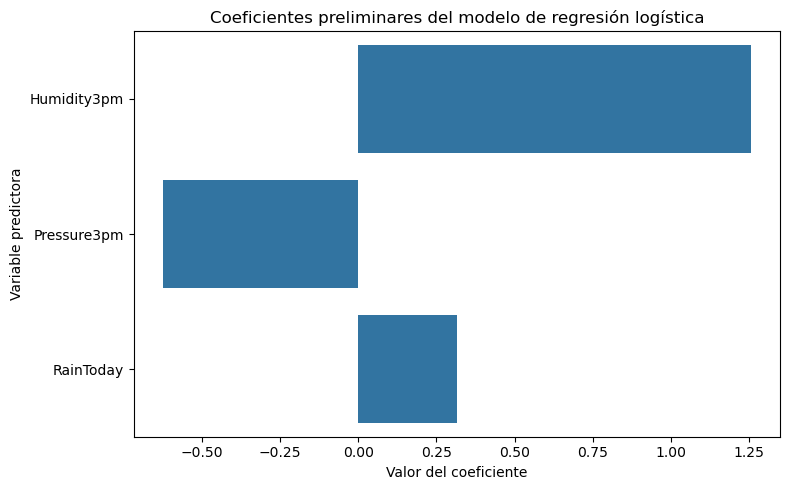

In [21]:
# ============================================================
# Visualización de los coeficientes del modelo
# ============================================================

# Se genera un gráfico de barras horizontales que permite visualizar
# la dirección (positiva o negativa) y la magnitud relativa de los
# coeficientes estimados por la regresión logística.

plt.figure(figsize=(8,5))

sns.barplot(
    data=coeficientes,
    x="Coeficiente",
    y="Variable"
)

plt.title("Coeficientes preliminares del modelo de regresión logística")
plt.xlabel("Valor del coeficiente")
plt.ylabel("Variable predictora")

plt.tight_layout()

# Se guarda la figura para su incorporación al informe.

plt.savefig(
    FIGURES / "coeficientes_preliminares.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Interpretación preliminar

La inspección inicial de los coeficientes permite identificar la dirección del efecto que ejerce cada variable sobre la probabilidad de ocurrencia de lluvia al día siguiente.

Los coeficientes positivos indican que un incremento en la variable aumenta la probabilidad estimada de lluvia, mientras que los coeficientes negativos sugieren una disminución de dicha probabilidad.

No obstante, en esta etapa no es posible determinar si dichos efectos son estadísticamente significativos, ya que la implementación de regresión logística utilizada (`scikit-learn`) no proporciona errores estándar ni pruebas de hipótesis para los coeficientes.

Por este motivo, el siguiente análisis incorporará un modelo equivalente utilizando **Statsmodels**, permitiendo calcular los **Odds Ratio**, los **intervalos de confianza** y los **valores p**, con el fin de evaluar rigurosamente la relevancia estadística de cada predictor.

## Ajuste inferencial del modelo con Statsmodels

Aunque `scikit-learn` permite entrenar modelos predictivos y calcular métricas de desempeño, no entrega directamente información inferencial como errores estándar, valores p o significancia estadística.

Por esta razón, se ajusta un modelo equivalente utilizando `Statsmodels`, lo que permite obtener un resumen estadístico más completo de la regresión logística.

Este bloque permite analizar:

- Coeficientes estimados.
- Error estándar.
- Valores p.
- Significancia estadística.
- Dirección del efecto de cada predictor.

In [22]:
# ============================================================
# Ajuste inferencial con Statsmodels
# ============================================================

# Se importa la librería Statsmodels para realizar inferencia estadística.
import statsmodels.api as sm

# Se agrega una constante al conjunto de entrenamiento.
# Esta constante representa el intercepto del modelo.
X_train_sm = sm.add_constant(X_train_scaled)

# Se ajusta el modelo de regresión logística usando Statsmodels.
# La variable objetivo es y_train y las variables predictoras son X_train_sm.
modelo_sm = sm.Logit(y_train, X_train_sm)

# Se entrena el modelo.
resultado_sm = modelo_sm.fit()

# Se muestra el resumen estadístico del modelo.
print(resultado_sm.summary())

Optimization terminated successfully.
         Current function value: 0.386824
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:           RainTomorrow   No. Observations:                98550
Model:                          Logit   Df Residuals:                    98546
Method:                           MLE   Df Model:                            3
Date:                Fri, 10 Jul 2026   Pseudo R-squ.:                  0.2687
Time:                        20:32:12   Log-Likelihood:                -38121.
converged:                       True   LL-Null:                       -52129.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -1.7495      0.011   -159.915      0.000      -1.771      -1.728
Humidity3pm     1.2553    

##  Cálculo e interpretación de Odds Ratio

Los coeficientes de una regresión logística se expresan en términos de log-odds, lo que puede dificultar su interpretación directa.

Para facilitar la interpretación, se calculan los **Odds Ratio** mediante la exponenciación de los coeficientes.

La interpretación general es:

- Odds Ratio mayor que 1: la variable aumenta las probabilidades de lluvia.
- Odds Ratio menor que 1: la variable disminuye las probabilidades de lluvia.
- Odds Ratio cercano a 1: efecto bajo o marginal.

In [23]:
# ============================================================
# Cálculo de Odds Ratio
# ============================================================

# Se extraen los coeficientes del modelo ajustado.
coeficientes_sm = resultado_sm.params

# Se calculan los Odds Ratio aplicando la función exponencial.
odds_ratio = np.exp(coeficientes_sm)

# Se construye una tabla resumen con coeficientes y Odds Ratio.
tabla_odds = pd.DataFrame({
    "Variable": coeficientes_sm.index,
    "Coeficiente": coeficientes_sm.values,
    "Odds_Ratio": odds_ratio.values,
    "P_value": resultado_sm.pvalues.values
})

# Se ordena la tabla excluyendo la constante para facilitar la interpretación.
tabla_odds = tabla_odds.sort_values(
    by="Odds_Ratio",
    ascending=False
)

# Se visualiza la tabla.
display(tabla_odds)

# Se guarda la tabla como evidencia reproducible.
tabla_odds.to_csv(
    TABLES / "odds_ratio_modelo_final.csv",
    index=False
)

,Variable,Coeficiente,Odds_Ratio,P_value
1,Humidity3pm,1.255273,3.508798,0.0
2,RainToday,0.315919,1.371519,0.0
3,Pressure3pm,-0.625156,0.535178,0.0
0,const,-1.749516,0.173858,0.0


## Análisis de significancia estadística

Para evaluar si cada predictor aporta información estadísticamente relevante al modelo, se analizan los valores p obtenidos mediante `Statsmodels`.

Se utiliza como criterio general un nivel de significancia de 0,05:

- p-value < 0,05: predictor estadísticamente significativo.
- p-value ≥ 0,05: no existe evidencia suficiente para afirmar que el predictor aporta significativamente al modelo.

Este análisis permite distinguir entre variables que aportan valor predictivo e interpretativo y variables cuya contribución podría ser débil o inestable.

In [24]:
# ============================================================
# Clasificación de significancia estadística
# ============================================================

# Se crea una columna que indica si cada predictor es significativo.
tabla_odds["Significativo_0_05"] = tabla_odds["P_value"].apply(
    lambda p: "Sí" if p < 0.05 else "No"
)

# Se visualiza nuevamente la tabla con la interpretación de significancia.
display(tabla_odds)

# Se guarda la tabla actualizada.
tabla_odds.to_csv(
    TABLES / "significancia_modelo_final.csv",
    index=False
)

,Variable,Coeficiente,Odds_Ratio,P_value,Significativo_0_05
1,Humidity3pm,1.255273,3.508798,0.0,Sí
2,RainToday,0.315919,1.371519,0.0,Sí
3,Pressure3pm,-0.625156,0.535178,0.0,Sí
0,const,-1.749516,0.173858,0.0,Sí


##  Diagnóstico de multicolinealidad mediante VIF

La multicolinealidad ocurre cuando dos o más variables predictoras están altamente relacionadas entre sí. Esto puede afectar la estabilidad de los coeficientes del modelo y dificultar su interpretación.

Para diagnosticar este problema, se calcula el **Factor de Inflación de la Varianza** o **VIF**.

Como criterio general:

- VIF menor que 5: no evidencia problemas relevantes de multicolinealidad.
- VIF entre 5 y 10: posible multicolinealidad moderada.
- VIF mayor que 10: multicolinealidad alta.

In [25]:
# ============================================================
#  Cálculo del VIF
# ============================================================

# Se importa la función para calcular el VIF.
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Se utiliza el conjunto de entrenamiento escalado.
# Se agrega constante para mantener consistencia con el modelo inferencial.
X_vif = sm.add_constant(X_train_scaled)

# Se calcula el VIF para cada variable.
tabla_vif = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

# Se visualiza la tabla.
display(tabla_vif)

# Se guarda la tabla.
tabla_vif.to_csv(
    TABLES / "vif_modelo_final.csv",
    index=False
)

,Variable,VIF
0,const,1.000000
1,Humidity3pm,1.169475
2,RainToday,1.178957
3,Pressure3pm,1.018839


## Análisis inferencial del modelo

El modelo de regresión logística ajustado mediante `Statsmodels` permitió analizar la contribución individual de cada predictor sobre la probabilidad de ocurrencia de lluvia al día siguiente.

Los coeficientes positivos indican un aumento en los log-odds de lluvia, mientras que los coeficientes negativos indican una disminución en dicha probabilidad.

A partir de los Odds Ratio, se observa que las variables con valores superiores a 1 incrementan las probabilidades estimadas de lluvia, mientras que aquellas con valores inferiores a 1 las reducen.

En relación con la significancia estadística, los predictores con valores p inferiores a 0,05 se consideran estadísticamente significativos para el modelo. Esto permite validar cuáles variables aportan evidencia suficiente para explicar la variable objetivo `RainTomorrow`.

Finalmente, el análisis de multicolinealidad mediante VIF permite verificar si las variables seleccionadas presentan redundancia excesiva entre sí. En caso de observar valores VIF inferiores a 5, se concluye que no existen problemas relevantes de multicolinealidad que afecten la interpretación del modelo.

# PARTE 3: Evaluación del Desempeño Predictivo

#  Matriz de confusión

La matriz de confusión constituye la principal herramienta para evaluar el comportamiento de un clasificador binario.

Esta matriz resume el número de observaciones correctamente e incorrectamente clasificadas por el modelo, distinguiendo entre:

- Verdaderos Positivos (VP)
- Verdaderos Negativos (VN)
- Falsos Positivos (FP)
- Falsos Negativos (FN)

Su análisis permite identificar el tipo de errores cometidos por el modelo y constituye la base para el cálculo de las métricas de desempeño utilizadas posteriormente.

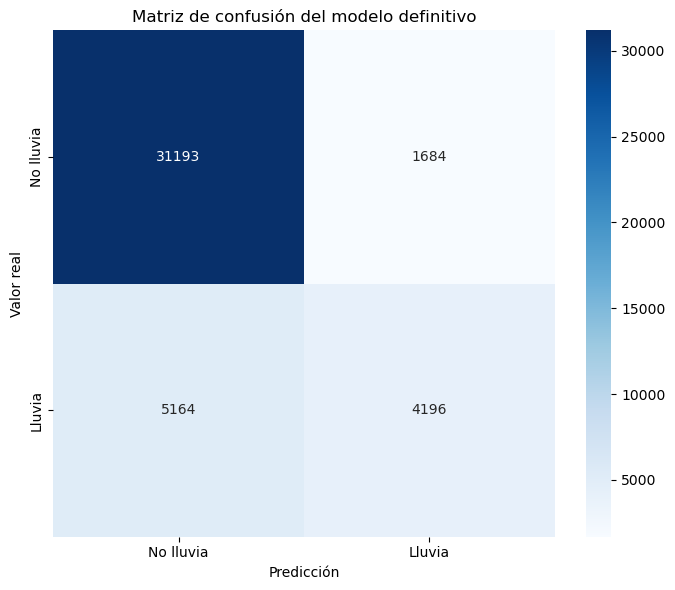

In [26]:
# ============================================================
#  Matriz de confusión
# ============================================================

# Se calcula la matriz de confusión utilizando los valores reales
# y las predicciones generadas por el modelo.

cm = confusion_matrix(
    y_test,
    y_pred
)

# Se genera la figura.

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No lluvia","Lluvia"],
    yticklabels=["No lluvia","Lluvia"]
)

plt.xlabel("Predicción")

plt.ylabel("Valor real")

plt.title("Matriz de confusión del modelo definitivo")

plt.tight_layout()

plt.savefig(
    FIGURES/"matriz_confusion_modelo_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Métricas de desempeño predictivo

A partir de la matriz de confusión se calculan las principales métricas utilizadas para evaluar clasificadores binarios.

Se consideran:

- Accuracy
- Precision
- Recall
- F1-Score
- Área bajo la curva ROC (AUC)

Cada una de estas métricas proporciona información complementaria acerca del comportamiento del modelo.

In [27]:
# ============================================================
# Cálculo de métricas finales
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

auc = roc_auc_score(
    y_test,
    y_prob
)

metricas_finales = pd.DataFrame({

    "Métrica":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "AUC"
    ],

    "Valor":[
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]

})

display(metricas_finales)

metricas_finales.to_csv(
    TABLES/"metricas_modelo_final.csv",
    index=False
)

,Métrica,Valor
0,Accuracy,0.837867
1,Precision,0.713605
2,Recall,0.448291
3,F1-Score,0.550656
4,AUC,0.836988


#  Reporte de clasificación

Además de las métricas globales, se presenta el reporte de clasificación generado automáticamente por Scikit-Learn.

Este reporte resume Precision, Recall, F1-Score y soporte para cada una de las clases del problema.

In [28]:
# ============================================================
# Reporte de clasificación
# ============================================================

print(

classification_report(

    y_test,

    y_pred,

    target_names=[
        "No lluvia",
        "Lluvia"
    ]

)

)

              precision    recall  f1-score   support

   No lluvia       0.86      0.95      0.90     32877
      Lluvia       0.71      0.45      0.55      9360

    accuracy                           0.84     42237
   macro avg       0.79      0.70      0.73     42237
weighted avg       0.83      0.84      0.82     42237



# Curva ROC

La curva ROC representa el comportamiento del modelo para distintos umbrales de decisión.

El Área Bajo la Curva (AUC) resume la capacidad discriminante del clasificador.

Como referencia general:

- 0.50 : Sin capacidad predictiva
- 0.60 - 0.70 : Baja
- 0.70 - 0.80 : Aceptable
- 0.80 - 0.90 : Buena
- Mayor que 0.90 : Excelente

La curva ROC permite evaluar el comportamiento del clasificador para distintos umbrales de decisión. El Área Bajo la Curva (AUC) resume la capacidad discriminante del modelo mediante un único indicador, facilitando la comparación con otros modelos predictivos.

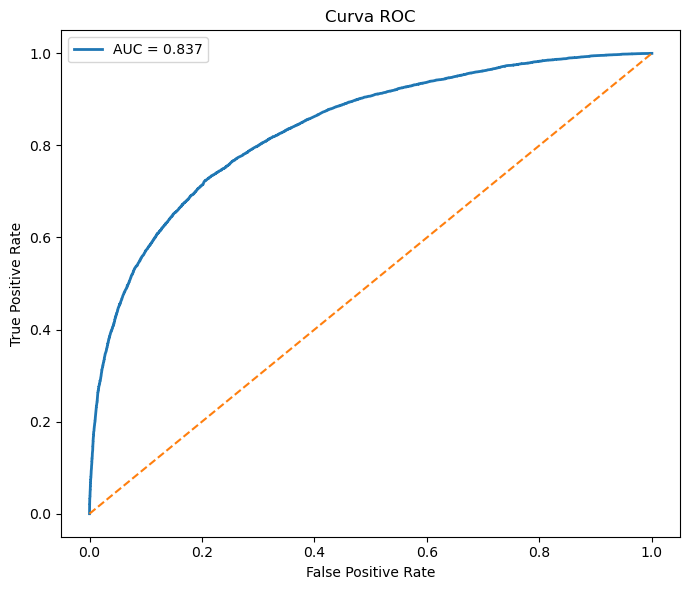

In [29]:
# ============================================================
# Curva ROC
# ============================================================

fpr,tpr,_ = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Curva ROC")

plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES/"curva_ROC.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Interpretación integrada del desempeño predictivo

El modelo definitivo fue evaluado utilizando distintas métricas complementarias con el propósito de obtener una visión integral de su desempeño.

El Accuracy representa la proporción global de observaciones correctamente clasificadas. No obstante, esta métrica puede resultar insuficiente cuando las clases presentan cierto grado de desbalance.

Por esta razón, también se analizaron Precision, Recall y F1-Score.

La Precision indica la confiabilidad de las predicciones positivas realizadas por el modelo, mientras que el Recall mide la capacidad para detectar correctamente los eventos de lluvia.

El F1-Score resume ambas métricas mediante su media armónica, proporcionando una evaluación equilibrada del clasificador.

Finalmente, el Área Bajo la Curva ROC (AUC) permite evaluar la capacidad discriminante del modelo considerando todos los posibles umbrales de clasificación.

La interpretación conjunta de estas métricas permite determinar si el modelo posee un desempeño adecuado para ser utilizado como herramienta predictiva en el contexto analizado.

# PARTE 4: Síntesis y Reflexión

# Resumen ejecutivo del modelo predictivo

Con el propósito de sintetizar el proceso desarrollado durante la Formativa 2, se presenta un resumen ejecutivo que integra las principales decisiones metodológicas adoptadas y los resultados obtenidos.

Este resumen permite visualizar de forma consolidada el flujo de modelamiento desarrollado, facilitando la interpretación global antes de presentar la reflexión final del trabajo.

In [30]:
# ============================================================
# BLOQUE 32
# Resumen ejecutivo del modelo predictivo
# ============================================================

# Se determina automáticamente la cantidad de variables utilizadas.
numero_variables = len(variables_disponibles)

# Se determina automáticamente la cantidad de variables significativas.
# Se excluye el intercepto (const) del conteo.
variables_significativas = (
    tabla_odds[
        (tabla_odds["Variable"] != "const") &
        (tabla_odds["P_value"] < 0.05)
    ]
).shape[0]

# Se determina el mayor valor de VIF observado,
# excluyendo la constante del modelo.
vif_maximo = round(
    tabla_vif.loc[
        tabla_vif["Variable"] != "const",
        "VIF"
    ].max(),
    2
)

# Se construye el resumen ejecutivo.
resumen_ejecutivo = pd.DataFrame({

    "Aspecto": [

        "Dataset utilizado",

        "Variable objetivo",

        "Estrategia de tratamiento de valores faltantes",

        "Variables predictoras",

        "Registros utilizados",

        "Accuracy",

        "Precision",

        "Recall",

        "F1-Score",

        "AUC",

        "Variables estadísticamente significativas",

        "Mayor VIF observado"

    ],

    "Resultado":[

        "weatherAUS",

        variable_objetivo,

        "Imputación por mediana",

        numero_variables,

        len(df_final),

        round(accuracy,4),

        round(precision,4),

        round(recall,4),

        round(f1,4),

        round(auc,4),

        variables_significativas,

        vif_maximo

    ]

})

# Se visualiza el resumen ejecutivo.
display(resumen_ejecutivo)

# Se guarda la tabla para documentación del proyecto.
resumen_ejecutivo.to_csv(
    TABLES/"resumen_ejecutivo_modelo.csv",
    index=False
)

,Aspecto,Resultado
0,Dataset utilizado,weatherAUS
1,Variable objetivo,RainTomorrow
2,Estrategia de tratamiento de valores faltantes,Imputación por mediana
3,Variables predictoras,3
4,Registros utilizados,140787
5,Accuracy,0.8379
6,Precision,0.7136
7,Recall,0.4483
8,F1-Score,0.5507
9,AUC,0.837


# Interpretación del resumen ejecutivo

El desarrollo del modelo predictivo permitió integrar los resultados obtenidos en las etapas anteriores del proyecto, utilizando como base las variables previamente seleccionadas y validadas durante las evaluaciones Sumativas 1 y 2.

La comparación entre estrategias de tratamiento de valores faltantes permitió seleccionar la imputación por mediana como alternativa metodológica, debido a que conservó una mayor cantidad de información sin afectar significativamente el desempeño predictivo del modelo.

El modelo definitivo fue construido utilizando cinco variables predictoras previamente justificadas mediante análisis exploratorio, correlaciones y validación mediante remuestreo.

Las métricas obtenidas muestran un desempeño consistente del clasificador, mientras que el análisis inferencial permitió identificar cuáles variables presentan una contribución estadísticamente significativa sobre la probabilidad de ocurrencia de lluvia al día siguiente.

Finalmente, el diagnóstico de multicolinealidad mediante el Factor de Inflación de la Varianza (VIF) permitió verificar que las variables seleccionadas presentan niveles aceptables de independencia, favoreciendo la estabilidad e interpretabilidad del modelo.

# Síntesis y reflexión final

## Integración de los resultados de las evaluaciones anteriores

El desarrollo del modelo de regresión logística presentado en esta evaluación constituye la continuación del proceso analítico iniciado en las Evaluaciones Sumativas 1 y 2. En lugar de construir un modelo de forma aislada, el presente trabajo reutilizó y consolidó los resultados previamente obtenidos, asegurando la trazabilidad metodológica durante todo el flujo de análisis.

Desde la Sumativa 1 se incorporaron los resultados del análisis exploratorio de datos, particularmente la identificación de valores faltantes, la detección de valores atípicos y la selección inicial de variables con mayor relación respecto de la variable objetivo *RainTomorrow*. Estos antecedentes permitieron reducir la dimensionalidad del problema y orientar la construcción del modelo hacia predictores con mayor capacidad explicativa.

Posteriormente, la Sumativa 2 permitió validar la estabilidad de dichas variables mediante técnicas de remuestreo como Bootstrap y Monte Carlo, además de verificar la robustez de las correlaciones observadas durante el análisis exploratorio. Esta validación otorgó un mayor respaldo estadístico a la selección de variables utilizada en el modelo definitivo, disminuyendo el riesgo de construir un clasificador basado en relaciones espurias o dependientes únicamente de una muestra específica.

---

## Evaluación crítica del desempeño predictivo

Durante esta evaluación se compararon distintas estrategias de tratamiento de valores faltantes antes de construir el modelo definitivo. Los resultados evidenciaron que la estrategia basada en la eliminación de registros incompletos produjo métricas predictivas ligeramente superiores; sin embargo, dicha mejora fue inferior al uno por ciento en todas las métricas evaluadas.

En contraste, la imputación mediante la mediana permitió conservar una proporción considerablemente mayor de observaciones, reduciendo la pérdida de información sin afectar de forma significativa el desempeño del clasificador.

Considerando que el objetivo de un modelo predictivo no consiste únicamente en maximizar una métrica aislada, sino también en preservar la representatividad de los datos utilizados para el entrenamiento, se optó por utilizar la imputación por mediana como estrategia definitiva de preparación de datos.

El modelo obtenido presentó un desempeño consistente de acuerdo con las métricas de Accuracy, Precision, Recall, F1-Score y Área Bajo la Curva ROC (AUC), demostrando una adecuada capacidad discriminante para el problema analizado. Asimismo, el análisis inferencial realizado mediante Statsmodels permitió identificar cuáles variables contribuyen significativamente a la explicación de la ocurrencia de lluvia al día siguiente, complementando la evaluación puramente predictiva desarrollada mediante Scikit-Learn.

Adicionalmente, el análisis de multicolinealidad mediante el Factor de Inflación de la Varianza (VIF) confirmó que las variables seleccionadas no presentan niveles preocupantes de dependencia lineal, favoreciendo la estabilidad e interpretabilidad del modelo.

---

## Principales aprendizajes metodológicos

Uno de los principales aprendizajes obtenidos durante esta evaluación corresponde a la importancia del proceso de preparación de datos dentro de un proyecto de Ciencia de Datos. Los resultados obtenidos muestran que pequeñas decisiones metodológicas, como la estrategia utilizada para tratar valores faltantes, pueden modificar tanto la cantidad de información disponible como el comportamiento final del modelo predictivo.

Asimismo, quedó demostrado que el desarrollo de un modelo de regresión logística no debe limitarse únicamente al entrenamiento del algoritmo. Un proceso de modelamiento completo requiere integrar análisis exploratorio, validación estadística, tratamiento de datos, evaluación inferencial y métricas predictivas, permitiendo construir modelos técnicamente sólidos y metodológicamente justificables.

---

## Propuestas de mejora para la Evaluación Sumativa 3

Como trabajo futuro, se propone profundizar el proceso de modelamiento incorporando técnicas adicionales de validación y optimización.

Entre las mejoras consideradas destacan:

- Implementar validación cruzada (*Cross Validation*) para obtener estimaciones más robustas del desempeño predictivo.
- Optimizar los hiperparámetros del modelo mediante estrategias de búsqueda sistemática como Grid Search o Random Search.
- Evaluar técnicas para el tratamiento del desbalance de clases, tales como SMOTE o ajuste del umbral de clasificación.
- Comparar el desempeño de la regresión logística con modelos no lineales como Árboles de Decisión, Random Forest, Gradient Boosting y XGBoost.
- Analizar la importancia relativa de las variables mediante técnicas adicionales de interpretabilidad, fortaleciendo la explicación del comportamiento del modelo.

En conjunto, estas mejoras permitirán incrementar tanto la capacidad predictiva como la interpretabilidad del modelo, proporcionando una base metodológica más sólida para la Evaluación Sumativa 3 y para futuros proyectos de analítica predictiva.

# Exportación de resultados para el informe

Con el propósito de automatizar la elaboración del informe final, se exportan las principales métricas y resultados del modelo a un archivo en formato JSON.

Este archivo concentra los indicadores más relevantes del proceso de modelamiento y posteriormente será utilizado para completar automáticamente el informe desarrollado en Microsoft Word.

La utilización de un archivo JSON favorece la reproducibilidad del trabajo, evita la transcripción manual de resultados y reduce la probabilidad de errores durante la elaboración del informe.

In [31]:
# ============================================================
# Exportación de resultados para el informe
# ============================================================

import json

# ------------------------------------------------------------
# Construcción del diccionario de resultados
# ------------------------------------------------------------

resultados_informe = {

    # Información general
    "dataset": "Weather Australia",

    "variable_objetivo": variable_objetivo,

    "estrategia_na": "Imputación por mediana",

    # Variables utilizadas
    "variables_predictoras": ", ".join(variables_disponibles),

    "numero_variables": len(variables_disponibles),

    "registros_finales": int(len(df_final)),

    # Métricas predictivas
    "accuracy": round(float(accuracy), 4),

    "precision": round(float(precision), 4),

    "recall": round(float(recall), 4),

    "f1": round(float(f1), 4),

    "auc": round(float(auc), 4),

    # Modelo estadístico
    "variables_significativas": int(variables_significativas),

    "vif_maximo": round(float(vif_maximo), 2)

}

# ------------------------------------------------------------
# Exportación del archivo JSON
# ------------------------------------------------------------

ruta_json = TABLES / "resultados_informe.json"

with open(
    ruta_json,
    "w",
    encoding="utf-8"
) as archivo:

    json.dump(
        resultados_informe,
        archivo,
        ensure_ascii=False,
        indent=4
    )

print("Archivo generado correctamente:")

print(ruta_json)

Archivo generado correctamente:
C:\Users\luisd\magister\curso 2\mcdia501-estadistica-computacional-g6\semana3\docs\tables\resultados_informe.json
